In [2]:
import nibabel as nib
from nilearn import plotting, datasets
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
# from enigmatoolbox.utils import parcel_to_surface, surface_to_parcel
import numpy as np
import pandas as pd
import itertools

%config InlineBackend.figure_format = 'retina'
# plt.style.use('default')

sns.set_theme(style='ticks', palette='bright')
sns.set_context('notebook') # talk
plt.style.use('dark_background') #

---

In [3]:
resolution = 'fsaverage'
fsaverage = datasets.fetch_surf_fsaverage(mesh=resolution)

In [4]:
schaefer = {
    'left': nib.freesurfer.io.read_annot(f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/lh.Schaefer2018_400Parcels_7Networks_order.annot')[0],
    'right': nib.freesurfer.io.read_annot(f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/rh.Schaefer2018_400Parcels_7Networks_order.annot')[0]
}
glasser = {
    'left': nib.freesurfer.io.read_annot('/RAID1/jupytertmp/mcm/data/external/hcp_mmp/lh.HCP-MMP1.annot')[0],
    'right': nib.freesurfer.io.read_annot('/RAID1/jupytertmp/mcm/data/external/hcp_mmp/rh.HCP-MMP1.annot')[0]
}
yeo = {
    'left': nib.freesurfer.io.read_annot(f'/RAID1/jupytertmp/mcm/data/external/yeo/Yeo_JNeurophysiol11_FreeSurfer/{resolution}/label/lh.Yeo2011_7Networks_N1000.annot')[0],
    'right': nib.freesurfer.io.read_annot(f'/RAID1/jupytertmp/mcm/data/external/yeo/Yeo_JNeurophysiol11_FreeSurfer/{resolution}/label/rh.Yeo2011_7Networks_N1000.annot')[0]
}

# All Schaefer labels of surface vertices (left and right hemis)
schaefer_all = np.concatenate([
    schaefer['left'], 
    np.where(schaefer['right'] != 0, schaefer['right'] + schaefer['left'].max(), 0)
])

glasser_all = np.concatenate([
    glasser['left'], 
    np.where(glasser['right'] != 0, glasser['right'] + glasser['left'].max(), 0)
])

yeo_all = np.concatenate([
    yeo['left'], 
    yeo['right']
])



# Overlap in fsaverage

In [5]:
cooccurrence = np.zeros(( np.unique(schaefer_all).size, np.unique(glasser_all).size ))

for schaefer_label in np.unique(schaefer_all):
        
    mask = schaefer_all == schaefer_label
    glasser_labels_in_mask = glasser_all[mask]
    glasser_labels_in_mask_nonzero = glasser_labels_in_mask[glasser_labels_in_mask != 0]
    
    unique, counts = np.unique(glasser_labels_in_mask_nonzero, return_counts=True)
    confidence = counts / mask.sum()
    
    cooccurrence[schaefer_label, unique] = confidence

In [6]:
df = pd.DataFrame(cooccurrence, index=np.unique(schaefer_all), columns=np.unique(glasser_all))

Text(28.75, 0.5, 'Schaefer ROI')

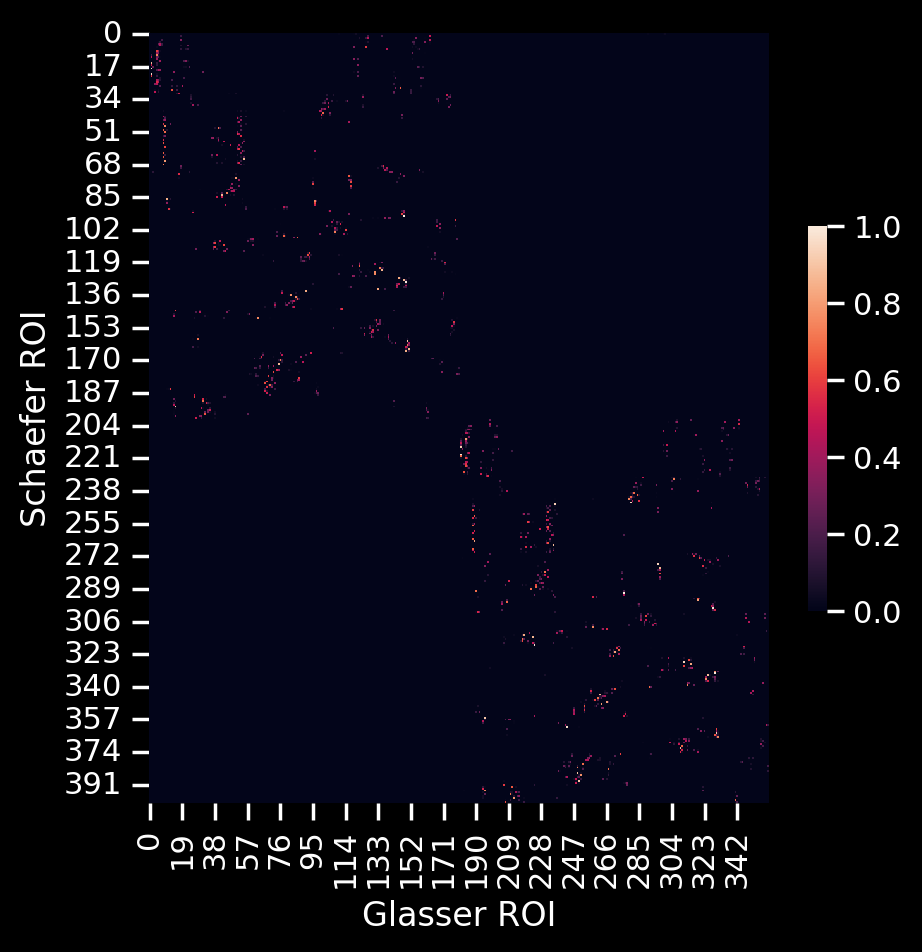

In [7]:
fig, ax = plt.subplots(1,1, figsize=(5, 5))
sns.heatmap(cooccurrence, ax=ax, cbar_kws={'shrink': 0.5})

ax.set_xlabel('Glasser ROI')
ax.set_ylabel('Schaefer ROI')

In [8]:
schaefer2glasser = np.argmax(cooccurrence, axis=1)
confidence = np.max(cooccurrence, axis=1)

In [9]:
list(zip(*np.unique(schaefer2glasser, return_counts=True)))

[(1, 6),
 (2, 1),
 (3, 1),
 (4, 7),
 (5, 1),
 (6, 3),
 (8, 8),
 (9, 5),
 (10, 1),
 (11, 1),
 (12, 1),
 (13, 1),
 (14, 3),
 (15, 2),
 (17, 2),
 (19, 1),
 (25, 2),
 (26, 2),
 (27, 1),
 (28, 1),
 (29, 1),
 (30, 2),
 (31, 2),
 (32, 1),
 (33, 1),
 (35, 1),
 (37, 1),
 (38, 2),
 (39, 2),
 (40, 1),
 (41, 1),
 (42, 1),
 (43, 2),
 (44, 1),
 (45, 2),
 (46, 1),
 (47, 2),
 (49, 1),
 (50, 1),
 (51, 2),
 (52, 4),
 (53, 1),
 (54, 1),
 (55, 1),
 (58, 1),
 (60, 1),
 (61, 1),
 (63, 1),
 (65, 1),
 (67, 2),
 (68, 3),
 (69, 1),
 (70, 1),
 (72, 2),
 (73, 1),
 (74, 1),
 (75, 1),
 (76, 1),
 (77, 2),
 (78, 2),
 (81, 1),
 (82, 1),
 (84, 2),
 (85, 1),
 (86, 2),
 (87, 2),
 (89, 1),
 (90, 1),
 (91, 1),
 (92, 1),
 (93, 2),
 (94, 1),
 (95, 1),
 (96, 3),
 (99, 1),
 (100, 1),
 (101, 1),
 (102, 1),
 (103, 1),
 (104, 2),
 (105, 1),
 (106, 1),
 (108, 2),
 (111, 1),
 (112, 1),
 (113, 1),
 (114, 1),
 (116, 1),
 (117, 2),
 (118, 1),
 (120, 1),
 (122, 1),
 (124, 1),
 (125, 2),
 (126, 1),
 (127, 1),
 (128, 1),
 (129, 2),
 (130

In [10]:
schaefer_roi_glasser_labels = np.zeros_like(schaefer_all)
schaefer_roi_glasser_confidence = np.zeros(schaefer_all.size)

for i, schaefer_label in enumerate(schaefer_all):
    
    if schaefer_label == 0:
        schaefer_roi_glasser_labels[i] = 0
        schaefer_roi_glasser_confidence[i] = 0
        continue
    
    schaefer_roi_glasser_labels[i] = schaefer2glasser[schaefer_label]
    schaefer_roi_glasser_confidence[i] = confidence[schaefer_label]
    
converted = {hemi:tex for hemi, tex in zip(['left', 'right'], np.split(schaefer_roi_glasser_labels, 2))}
converted['right'] = np.where(converted['right'] != 0, converted['right'] - 180, 0)

conf = {hemi:tex for hemi, tex in zip(['left', 'right'], np.split(schaefer_roi_glasser_confidence, 2))}

In [11]:
(
    pd.DataFrame(dict(roi=glasser2yeo[1:]))
    .merge(pd.DataFrame(dict(roi=np.arange(1,8), label=['Vis', 'SomMot', 'DAN', 'VAN', 'Limbic', 'Control', 'Default'])))
    .label
    .to_numpy()
)

NameError: name 'glasser2yeo' is not defined

---

# Primary sensory and motor cortices on Schaefer Parcellation

### Glasser Primary and early Visual cortex

In [12]:
V1, = np.where( (schaefer2glasser == 1) | (schaefer2glasser == 181) )
V2, = np.where( (schaefer2glasser == 4) | (schaefer2glasser == 180+4) )
V3, = np.where( (schaefer2glasser == 5) | (schaefer2glasser == 180+5) )
V4, = np.where( (schaefer2glasser == 6) | (schaefer2glasser == 180+6) )

v1_tex = np.where( np.isin(schaefer_all, V1), 1, 0 )
v2_tex = np.where( np.isin(schaefer_all, V2), 2, 0 )
v3v4_tex = np.where( np.isin(schaefer_all, np.concatenate([V3,V4])), 3, 0 )

### Glasser Dorsal stream

In [17]:
V3A, = np.where( (schaefer2glasser == 13) | (schaefer2glasser == 180+13) )
V3B, = np.where( (schaefer2glasser == 19) | (schaefer2glasser == 180+19) )
V6, = np.where( (schaefer2glasser == 3) | (schaefer2glasser == 180+3) )
V6A, = np.where( (schaefer2glasser == 152) | (schaefer2glasser == 180+152) )
V7, = np.where( (schaefer2glasser == 16) | (schaefer2glasser == 180+16) )
IPS1, = np.where( (schaefer2glasser == 17) | (schaefer2glasser == 180+17) )

dorsal_tex = np.where( np.isin(schaefer_all, np.concatenate([V3A,V3B,V6,V6A,V7,IPS1])), 4, 0 )


### Glasser ventral stream

In [18]:
V8, = np.where( (schaefer2glasser == 7) | (schaefer2glasser == 180+7) )
VVC, = np.where( (schaefer2glasser == 163) | (schaefer2glasser == 180+163) ) # ventral visual cortex
PIT, = np.where( (schaefer2glasser == 22) | (schaefer2glasser == 180+22) ) # posterior inferiotemporal cortex
FFC, = np.where( (schaefer2glasser == 18) | (schaefer2glasser == 180+18) ) # posterior inferiotemporal cortex
VMV1, = np.where( (schaefer2glasser == 153) | (schaefer2glasser == 180+153) ) # ventromedial visual areas
VMV2, = np.where( (schaefer2glasser == 160) | (schaefer2glasser == 180+160) )
VMV3, = np.where( (schaefer2glasser == 154) | (schaefer2glasser == 180+154) )

ventral_tex = np.where( np.isin(schaefer_all, np.concatenate([V8,VVC,PIT,FFC,VMV1,VMV2,VMV3])), 5, 0 )

### Lateral occipital and posterior temporal areas

In [19]:
V3CD, = np.where( (schaefer2glasser == 158) | (schaefer2glasser == 180+158) )
LO1, = np.where( (schaefer2glasser == 20) | (schaefer2glasser == 180+20) )
LO2, = np.where( (schaefer2glasser == 21) | (schaefer2glasser == 180+21) )
LO3, = np.where( (schaefer2glasser == 159) | (schaefer2glasser == 180+159) )
V4t, = np.where( (schaefer2glasser == 156) | (schaefer2glasser == 180+156) )
FST, = np.where( (schaefer2glasser == 157) | (schaefer2glasser == 180+157) )
MT, = np.where( (schaefer2glasser == 23) | (schaefer2glasser == 180+23) )
MST, = np.where( (schaefer2glasser == 2) | (schaefer2glasser == 180+2) )
PH, = np.where( (schaefer2glasser == 138) | (schaefer2glasser == 180+138) )

lopt_tex = np.where( np.isin(schaefer_all, np.concatenate([V3CD,LO1,LO2,LO3,V4t,FST,MT,MST,PH])), 6, 0 )

### Superior parietal

In [20]:
MIP, = np.where( (schaefer2glasser == 50) | (schaefer2glasser == 180+50) )
LIPv, = np.where( (schaefer2glasser == 48) | (schaefer2glasser == 180+48) )
LIPd, = np.where( (schaefer2glasser == 95) | (schaefer2glasser == 180+95) )
VIP, = np.where( (schaefer2glasser == 49) | (schaefer2glasser == 180+49) )
AIP, = np.where( (schaefer2glasser == 117) | (schaefer2glasser == 180+117) )
a7PC, = np.where( (schaefer2glasser == 47) | (schaefer2glasser == 180+47) )
a7AL, = np.where( (schaefer2glasser == 42) | (schaefer2glasser == 180+42) )
a7Am, = np.where( (schaefer2glasser == 45) | (schaefer2glasser == 180+45) )
a7PL, = np.where( (schaefer2glasser == 46) | (schaefer2glasser == 180+46) )
a7Pm, = np.where( (schaefer2glasser == 29) | (schaefer2glasser == 180+29) )

# a7_tex = np.where( np.isin(schaefer_all, np.concatenate([a7PC,a7AL,a7Am,a7PL,a7Pm])), 7, 0 )
sp_tex = np.where( np.isin(schaefer_all, np.concatenate([MIP,LIPv,LIPd,VIP,AIP,a7PC,a7AL,a7Am,a7PL,a7Pm])), 7, 0 )

### Temporo parieto occipital junction

In [21]:
TPOJ1, = np.where( (schaefer2glasser ==139) | (schaefer2glasser == 180+139) )
TPOJ2, = np.where( (schaefer2glasser ==140) | (schaefer2glasser == 180+140) )
TPOJ3, = np.where( (schaefer2glasser ==141) | (schaefer2glasser == 180+141) )
STV, = np.where( (schaefer2glasser == 28) | (schaefer2glasser == 180+28) ) # superior temporal
PSL, = np.where( (schaefer2glasser == 25) | (schaefer2glasser == 180+25) )

tpoj_tex = np.where( np.isin(schaefer_all, np.concatenate([TPOJ1,TPOJ2,TPOJ3,STV,PSL])), 8, 0 )

### Posterior cingulate

In [22]:
PCV, = np.where( (schaefer2glasser == 27) | (schaefer2glasser == 180+27) ) # precuneus visual area
DVT, = np.where( (schaefer2glasser == 142) | (schaefer2glasser == 180+142) ) # dorsal transitional visual area
Pros, = np.where( (schaefer2glasser == 121) | (schaefer2glasser == 180+121) ) # Prostriate

pc_tex = np.where( np.isin(schaefer_all, np.concatenate([PCV,DVT,Pros])), 9, 0 )

### Premotor cortex

In [23]:
FEF, = np.where( (schaefer2glasser == 10) | (schaefer2glasser == 180+10) )
PEF, = np.where( (schaefer2glasser == 11) | (schaefer2glasser == 180+11) )

prem_tex = np.where( np.isin(schaefer_all, np.concatenate([FEF,PEF])), 10, 0 )

In [24]:
VIS_TEX = v1_tex + v2_tex + v3v4_tex  + dorsal_tex + ventral_tex + lopt_tex + sp_tex + tpoj_tex + prem_tex
labels = ['V1', 'V2', 'V3/V4', 'Dorsal', 'Ventral', 'LO/PT', 'SP', 'TPOJ', 'PMC'] 

In [ ]:
regions = {region: {} for region in ['V1', 'V2', 'V3/V4', 'Dorsal', 'Ventral']}

regions['V1']['labels'] = V1
regions['V2']['labels'] = V2
regions['V3/V4']['labels'] = np.concatenate([V3, V4])
regions['Dorsal']['labels'] = np.concatenate([V3A,V3B,V6,V6A,V7,IPS1])
regions['Ventral']['labels'] = np.concatenate([V8,VVC,PIT,FFC,VMV1,VMV2,VMV3])
# regions['LO/PT']['labels'] = np.concatenate([V3CD,LO1,LO2,LO3,V4t,FST,MT,MST,PH])
# regions['SP']['labels'] = np.concatenate([MIP,LIPv,LIPd,VIP,AIP,a7PC,a7AL,a7Am,a7PL,a7Pm])
# regions['TPOJ']['labels'] = np.concatenate([TPOJ1,TPOJ2,TPOJ3,STV,PSL])
# regions['PCC']['labels'] = np.concatenate([PCV,DVT,Pros])
# regions['PMC']['labels'] = np.concatenate([FEF,PEF])

vis_tex = {}
vis_tex['vis_tex'] = v1_tex + v2_tex + v3v4_tex  + dorsal_tex + ventral_tex
vis_tex['labels'] = labels = ['V1', 'V2', 'V3/V4', 'Dorsal', 'Ventral'] 

import joblib
joblib.dump(regions, '/RAID1/jupytertmp/mcm/vis_regions.joblib')
joblib.dump(vis_tex, '/RAID1/jupytertmp/mcm/vis_tex.joblib')

# Sensrymotor 

## Primary motor cortex

In [9]:
M1, = np.where( (schaefer2glasser == 8) | (schaefer2glasser == 180+8) )

m1_labels = M1
m1_tex = np.where( np.isin(schaefer_all, M1), 1, 0 )

## Primary sensory cortex

In [10]:
A3b, = np.where( (schaefer2glasser == 9) | (schaefer2glasser == 180+9) )
A1, = np.where( (schaefer2glasser == 51) | (schaefer2glasser == 180+51) )
A2, = np.where( (schaefer2glasser == 52) | (schaefer2glasser == 180+52) )
A3a, = np.where( (schaefer2glasser == 53) | (schaefer2glasser == 180+53) )

s1_labels = np.concatenate([A3b, A1, A2, A3a])
s1_tex = np.where( np.isin(schaefer_all, s1_labels), 2, 0 )

## Premotor cortex

In [11]:
A6d, = np.where( (schaefer2glasser == 54) | (schaefer2glasser == 180+54) )
A6a, = np.where( (schaefer2glasser == 96) | (schaefer2glasser == 180+96) )
FEF, = np.where( (schaefer2glasser == 10) | (schaefer2glasser == 180+10) )
A55b, = np.where( (schaefer2glasser == 12) | (schaefer2glasser == 180+12) )
A6v, = np.where( (schaefer2glasser == 56) | (schaefer2glasser == 180+56) )
A6r, = np.where( (schaefer2glasser == 78) | (schaefer2glasser == 180+78) )
PEF, = np.where( (schaefer2glasser == 11) | (schaefer2glasser == 180+11) )

# pmcd_labels = np.concatenate([A6d, A6a, FEF])
# pmcd_tex = np.where( np.isin(schaefer_all, pmcd_labels), 3, 0 )

# pmcv_labels = np.concatenate([A55b, A6v, A6r, PEF])
# pmcv_tex = np.where( np.isin(schaefer_all, pmcv_labels), 4, 0 )

pmc_labels = np.concatenate([A6d, A6a, FEF, A55b, A6v, A6r, PEF])
pmc_tex = np.where( np.isin(schaefer_all, pmc_labels), 3, 0 )

## Supplementary motor cortex

In [12]:
SCEF, = np.where( (schaefer2glasser == 43) | (schaefer2glasser == 180+43) )
A6ma, = np.where( (schaefer2glasser == 44) | (schaefer2glasser == 180+44) )
A6mp, = np.where( (schaefer2glasser == 55) | (schaefer2glasser == 180+55) )

sma_labels = np.concatenate([SCEF, A6ma, A6mp])
sma_tex = np.where( np.isin(schaefer_all, sma_labels), 4, 0 )

In [ ]:
sma_labels

## Cingulate motor cortex

In [13]:
A24dd, = np.where( (schaefer2glasser == 40) | (schaefer2glasser == 180+40) )
A24dv, = np.where( (schaefer2glasser == 41) | (schaefer2glasser == 180+41) )

cmc_labels = np.concatenate([A24dd, A24dv])
cmc_tex = np.where( np.isin(schaefer_all, cmc_labels), 5, 0 )

In [14]:
# SM_TEX = s1_tex + m1_tex + pmcd_tex + pmcv_tex + sma_tex + cmc_tex
# names = ['S1', 'M1', 'PMCd', 'PMCv', 'SMA', 'Cing', 'Caud', 'Put', 'Pal', 'Thal']
# labels = [s1_labels, m1_labels, pmcd_labels, pmcv_labels, sma_labels, cmc_labels, caud_labels, put_labels, pal_labels, thal_labels]

SM_TEX = m1_tex + s1_tex + pmc_tex + sma_tex + cmc_tex
names = ['M1', 'S1', 'PMC', 'SMA', 'Cing']
labels = [m1_labels, s1_labels, pmc_labels, sma_labels, cmc_labels]

# Posterior cingulate cortex

DVT,	ProS,	POS1,	POS2,	RSC,	v23ab,	d23ab,	 31pv,	31pd,	31a,	23d,	23c,	PCV,	and	7m

In [43]:
DVT, = np.where( (schaefer2glasser == 142) | (schaefer2glasser == 180+142) )
ProS, = np.where( (schaefer2glasser == 121) | (schaefer2glasser == 180+121) )
POS1, = np.where( (schaefer2glasser == 31) | (schaefer2glasser == 180+31) )
POS2, = np.where( (schaefer2glasser == 15) | (schaefer2glasser == 180+15) )
RSC, = np.where( (schaefer2glasser == 14) | (schaefer2glasser == 180+14) )
v23ab, = np.where( (schaefer2glasser == 33) | (schaefer2glasser == 180+33) )
d23ab, = np.where( (schaefer2glasser == 34) | (schaefer2glasser == 180+34) )
A31pv, = np.where( (schaefer2glasser == 35) | (schaefer2glasser == 180+35) )
A31pd, = np.where( (schaefer2glasser == 161) | (schaefer2glasser == 180+161) )
A31a, = np.where( (schaefer2glasser == 162) | (schaefer2glasser == 180+162) )
A23d, = np.where( (schaefer2glasser == 32) | (schaefer2glasser == 180+32) )
A23c, = np.where( (schaefer2glasser == 38) | (schaefer2glasser == 180+38) )
PCV, = np.where( (schaefer2glasser == 27) | (schaefer2glasser == 180+27) )
A7m, = np.where( (schaefer2glasser == 30) | (schaefer2glasser == 180+30) )

pcc_labels = np.concatenate([DVT, ProS, POS1, POS2, RSC, v23ab, d23ab, A31pv, A31pd, A31a, A23d, A23c, PCV, A7m])

## Save the regions 

In [ ]:
regions = {region: {} for region in names}

for name, label in zip(names, labels):
    regions[name]['labels'] = label

sm_tex = {}
sm_tex['tex'] = SM_TEX
sm_tex['labels'] = names

import joblib
joblib.dump(regions, '/RAID1/jupytertmp/mcm/sm_regions.joblib')
joblib.dump(sm_tex, '/RAID1/jupytertmp/mcm/sm_tex.joblib')

---

In [ ]:
import matplotlib.patches as mpatches
import matplotlib as mpl 

surf = {hemi:tex for hemi,tex in zip(['left', 'right'], np.split(SM_TEX, 2))}

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, constrained_layout=False, figsize=(8,8))
fig.subplots_adjust(wspace=0, hspace=0)
axs = axs.flatten()

for ax, (view, hemi) in zip(axs, itertools.product(['lateral', 'medial'], ['left', 'right'])):

    plotting.plot_surf(
        surf_mesh=fsaverage[f'infl_{hemi}'], 
        surf_map=surf[hemi],
        bg_map=fsaverage[f'sulc_{hemi}'], 
        hemi=hemi, view=view, 
        darkness=0.5,
        bg_on_data=True,
        axes=ax, figure=fig,
        cmap='tab10',
        vmin=1, vmax=10,
        threshold=1)

    plotting.plot_surf_contours(fsaverage[f'infl_{hemi}'], schaefer[hemi],
                                colors=['k']*201, figure=fig, axes=ax)

cmap  = mpl.colormaps['tab10']
patches = [mpatches.Patch(color=cmap.colors[i], label=names[i]) for i in range(len(names))]
fig.legend(patches, names, loc='center', frameon=False, alignment='center', fontsize=6, ncol=2);

for ax in axs:
    ax.dist = 6.5

# for ax, azim in zip(axs, [200, -20, 310, 230]):
#     ax.azim = azim

# Using Enigma

In [ ]:
schaefer_glasser = surface_to_parcel(parcel_to_surface(np.arange(1,361), 'glasser_360_fsa5'), 'schaefer_400_fsa5', red_op='mode')

In [ ]:
schaefer_labels = pd.read_csv('/RAID1/jupytertmp/mcm/schaefer/Schaefer2018_400Parcels_7Networks_order.lut', sep=' ', header=None)
glasser_labels = pd.read_csv('/RAID1/jupytertmp/mcm/hcp_mmp/glasser_table.csv')

glasser_labels.columns = ['roi', 'area_name', 'area_desc', 'new', 'sections', 'othernames', 'references']
schaefer_labels.columns = ['roi', 'r', 'g', 'b', 'name']

In [ ]:
schaefer_labels['glasser_roi'] = schaefer_glasser[1:]
schaefer_labels['glasser_roi_180'] = np.where(schaefer_labels['glasser_roi'] > 180, schaefer_labels['glasser_roi'] - 180, schaefer_labels['glasser_roi'])
schaefer_labels = schaefer_labels.merge(glasser_labels[['roi', 'area_desc']], left_on='glasser_roi_180', right_on='roi', how='left')

In [ ]:
motor_rois = schaefer_labels.loc[schaefer_labels.glasser_roi.isin([8,189]), 'roi_x'].to_numpy()
sensory_rois = schaefer_labels.loc[schaefer_labels.glasser_roi.isin([9,190]), 'roi_x'].to_numpy()

In [ ]:
sommot = {
    'left': np.where(np.isin(schaefer['left'][0], motor_rois), 1, 0) + np.where(np.isin(schaefer['left'][0], sensory_rois), 2, 0),
    'right': np.where(np.isin(schaefer['right'][0], motor_rois), 1, 0) + np.where(np.isin(schaefer['right'][0], sensory_rois), 2, 0)
}

use conte instead of fsa5

In [ ]:
schaefer = {
    'left': nib.freesurfer.io.read_annot('/RAID1/jupytertmp/mcm/schaefer/fsaverage5/lh.Schaefer2018_400Parcels_7Networks_order.annot'),
    'right': nib.freesurfer.io.read_annot('/RAID1/jupytertmp/mcm/schaefer/fsaverage5/rh.Schaefer2018_400Parcels_7Networks_order.annot')
}

glasser = {hemi:tex for hemi, tex in zip(['left', 'right'], np.split(parcel_to_surface(np.arange(1,401), 'glasser_360_fsa5'), 2) )}

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(10,10))
axs = axs.flatten()

for i, (hemi, view) in enumerate(itertools.product(['left', 'right'], ['lateral', 'medial'])):
    plotting.plot_surf_roi(fsaverage[f'infl_{hemi}'], 
                            glasser[hemi], 
                            bg_map=fsaverage[f'sulc_{hemi}'], 
                            hemi=hemi, view=view, 
                            darkness=0.5,
                            cmap=LinearSegmentedColormap.from_list(name='', colors=nib.freesurfer.io.read_annot('/RAID1/jupytertmp/mcm/hcp_mmp/rh.HCP-MMP1.annot')[1][:,:-2]/255),
                            bg_on_data=True,
                            axes=axs[i], figure=fig);
    # plotting.plot_surf_contours(fsaverage[f'infl_{hemi}'], schaefer[hemi][0],
                                # colors=['k']*201, figure=fig, axes=axs[i]);